# Formatos de Dados e Ferramentas — Notebook 5/5 (versão 2h)

## Aula: Localização, Detecção e Segmentação de Objetos

**Prof. Dr. Rooney Coelho** — Aprendizagem de Máquina (CDIA)

### Objetivo

Aprender, na prática, a **ler**, **escrever** e **converter** anotações entre os três formatos dominantes em detecção de objetos — **COCO**, **Pascal VOC** e **YOLO** — e conhecer as principais **ferramentas de anotação** usadas em projetos reais (Roboflow, CVAT, Label Studio, LabelImg).

### O que vamos cobrir

1. Criação de um *dataset* sintético em memória (3 imagens, 2 classes).
2. Formato **COCO** (`.json` único) — escrita e leitura.
3. Formato **Pascal VOC** (`.xml` por imagem) — escrita e leitura.
4. Formato **YOLO** (`.txt` por imagem + `data.yaml`) — escrita e leitura.
5. Conversões: **COCO → YOLO** e **Pascal VOC → COCO**.
6. Verificação cruzada visual: ler de qualquer formato e desenhar as mesmas caixas.
7. Ferramentas de anotação: Roboflow, CVAT, Label Studio (e LabelImg).
8. Boas práticas em anotação e organização de *datasets*.

### Pré-requisitos

Familiaridade com os notebooks anteriores (1 a 4) — caixas em `xyxy`/`xywh`, classes, *splits*. O notebook é totalmente *offline* (dados sintéticos), não usa GPU e roda em alguns segundos.


## 1. Importações

Carregamos bibliotecas padrão para JSON, XML, YAML e manipulação de arquivos. `pyyaml` é necessário para o formato YOLO (`data.yaml`); se não estiver instalado, descomente a linha abaixo.

In [1]:
# !pip install pyyaml  # descomente se necessário

import json
import os
import xml.etree.ElementTree as ET
from pathlib import Path
from xml.dom import minidom

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

try:
    import yaml
    print("pyyaml OK, versao", yaml.__version__)
except ImportError:
    raise SystemExit("Instale pyyaml: pip install pyyaml")

SEED = 42
np.random.seed(SEED)

print("Importacoes concluidas.")


pyyaml OK, versao 6.0.3
Importacoes concluidas.


## 2. Dataset sintético em memória

Para tornar as diferenças entre formatos **concretas**, criamos um pequeno *dataset* de 3 imagens 640x480 com 2 classes (`quadrado` e `circulo`). Em seguida, salvaremos as mesmas anotações nos três formatos e compararemos os arquivos gerados.

A estrutura unificada (independente de formato) é uma lista de dicionários:

```python
{
    "file_name": "img001.jpg",
    "image": np.ndarray (H, W, 3) uint8,
    "width": 640, "height": 480,
    "annotations": [
        {"bbox_xyxy": [x1, y1, x2, y2], "category_id": int, "category_name": str},
        ...
    ]
}
```


In [2]:
W, H = 640, 480
CLASSES = ["quadrado", "circulo"]   # 0 e 1
NUM_CLASSES = len(CLASSES)
CORES_PLOT = ["#1f77b4", "#d62728"]  # para visualizacao

rng = np.random.default_rng(SEED)


def _imagem_sintetica(n_objetos, rng):
    """Cria uma imagem RGB 640x480 com retangulos coloridos e devolve (img, anotacoes)."""
    img = np.full((H, W, 3), 220, dtype=np.uint8)  # fundo cinza claro
    anots = []
    for _ in range(n_objetos):
        cat_id = int(rng.integers(0, NUM_CLASSES))
        bw = int(rng.integers(60, 160))
        bh = int(rng.integers(60, 160))
        x1 = int(rng.integers(0, W - bw))
        y1 = int(rng.integers(0, H - bh))
        x2, y2 = x1 + bw, y1 + bh
        cor = rng.integers(40, 220, size=3, dtype=np.int32)
        img[y1:y2, x1:x2] = cor.astype(np.uint8)
        anots.append({
            "bbox_xyxy": [x1, y1, x2, y2],
            "category_id": cat_id,
            "category_name": CLASSES[cat_id],
        })
    return img, anots


dataset = []
for i in range(3):
    n = int(rng.integers(2, 4))  # 2 ou 3 objetos
    img, anots = _imagem_sintetica(n, rng)
    dataset.append({
        "file_name": f"img{i+1:03d}.jpg",
        "image": img,
        "width": W,
        "height": H,
        "annotations": anots,
    })

for amostra in dataset:
    print(amostra["file_name"], "->", len(amostra["annotations"]), "objetos")
    for a in amostra["annotations"]:
        print("   ", a)


img001.jpg -> 2 objetos
    {'bbox_xyxy': [223, 323, 348, 426], 'category_id': 1, 'category_name': 'circulo'}
    {'bbox_xyxy': [388, 245, 500, 402], 'category_id': 0, 'category_name': 'quadrado'}
img002.jpg -> 2 objetos
    {'bbox_xyxy': [198, 67, 303, 177], 'category_id': 1, 'category_name': 'circulo'}
    {'bbox_xyxy': [220, 164, 362, 278], 'category_id': 0, 'category_name': 'quadrado'}
img003.jpg -> 3 objetos
    {'bbox_xyxy': [136, 213, 281, 355], 'category_id': 0, 'category_name': 'quadrado'}
    {'bbox_xyxy': [255, 288, 321, 445], 'category_id': 0, 'category_name': 'quadrado'}
    {'bbox_xyxy': [270, 16, 366, 122], 'category_id': 0, 'category_name': 'quadrado'}


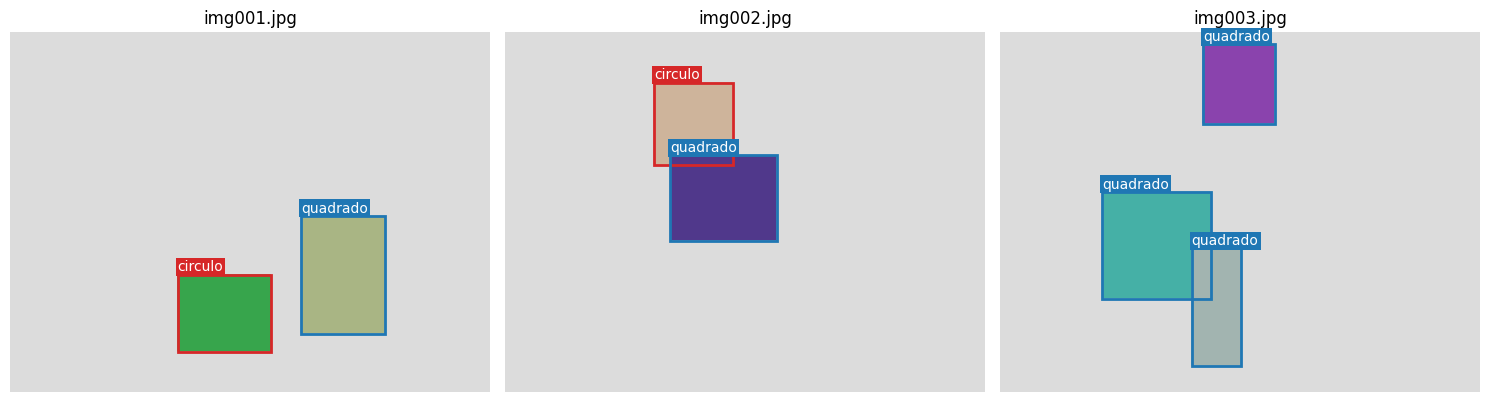

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, amostra in zip(axes, dataset):
    ax.imshow(amostra["image"])
    for a in amostra["annotations"]:
        x1, y1, x2, y2 = a["bbox_xyxy"]
        cor = CORES_PLOT[a["category_id"]]
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, edgecolor=cor, linewidth=2))
        ax.text(x1, max(0, y1 - 5), a["category_name"],
                color="white", fontsize=10,
                bbox=dict(facecolor=cor, edgecolor="none", pad=1.5))
    ax.set_title(amostra["file_name"])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
DEMO_DIR = Path("dataset_demo")
IMG_DIR = DEMO_DIR / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

for amostra in dataset:
    caminho = IMG_DIR / amostra["file_name"]
    Image.fromarray(amostra["image"]).save(caminho, "JPEG", quality=92)
    print("Salvo:", caminho)


Salvo: dataset_demo/images/img001.jpg
Salvo: dataset_demo/images/img002.jpg
Salvo: dataset_demo/images/img003.jpg


## 3. Formato COCO (JSON único)

O formato **COCO** (Common Objects in Context) reúne **todo o *dataset* num único arquivo JSON** com três listas principais:

- `images`: metadados de cada imagem (`id`, `file_name`, `width`, `height`).
- `annotations`: uma entrada por objeto (`id`, `image_id`, `category_id`, `bbox`, `area`, `iscrowd`).
- `categories`: dicionário de classes (`id`, `name`).

Particularidade importante: o **bbox em COCO é `[x, y, w, h]`** (canto superior esquerdo + largura/altura), em **pixels**.

In [5]:
def escrever_coco(dataset, classes, caminho_json):
    coco = {
        "info": {"description": "Dataset sintetico - aula", "version": "1.0"},
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [
            {"id": i, "name": nome, "supercategory": "forma"}
            for i, nome in enumerate(classes)
        ],
    }
    ann_id = 1
    for img_id, amostra in enumerate(dataset, start=1):
        coco["images"].append({
            "id": img_id,
            "file_name": amostra["file_name"],
            "width": amostra["width"],
            "height": amostra["height"],
        })
        for a in amostra["annotations"]:
            x1, y1, x2, y2 = a["bbox_xyxy"]
            w_box, h_box = x2 - x1, y2 - y1
            coco["annotations"].append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": a["category_id"],
                "bbox": [x1, y1, w_box, h_box],   # COCO: xywh
                "area": float(w_box * h_box),
                "iscrowd": 0,
                "segmentation": [],
            })
            ann_id += 1
    Path(caminho_json).parent.mkdir(parents=True, exist_ok=True)
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2, ensure_ascii=False)
    return coco


CAMINHO_COCO = DEMO_DIR / "annotations_coco.json"
coco_dict = escrever_coco(dataset, CLASSES, CAMINHO_COCO)

print("Arquivo:", CAMINHO_COCO)
print("Imagens   :", len(coco_dict["images"]))
print("Anotacoes :", len(coco_dict["annotations"]))
print("Categorias:", coco_dict["categories"])
print()
print("--- Primeiros 400 caracteres do JSON ---")
print(CAMINHO_COCO.read_text(encoding="utf-8")[:400])


Arquivo: dataset_demo/annotations_coco.json
Imagens   : 3
Anotacoes : 7
Categorias: [{'id': 0, 'name': 'quadrado', 'supercategory': 'forma'}, {'id': 1, 'name': 'circulo', 'supercategory': 'forma'}]

--- Primeiros 400 caracteres do JSON ---
{
  "info": {
    "description": "Dataset sintetico - aula",
    "version": "1.0"
  },
  "licenses": [],
  "images": [
    {
      "id": 1,
      "file_name": "img001.jpg",
      "width": 640,
      "height": 480
    },
    {
      "id": 2,
      "file_name": "img002.jpg",
      "width": 640,
      "height": 480
    },
    {
      "id": 3,
      "file_name": "img003.jpg",
      "width": 640,
     


In [6]:
# Leitura "na mao" com json.load
with open(CAMINHO_COCO, "r", encoding="utf-8") as f:
    coco_lido = json.load(f)

print("Anotacoes lidas do JSON:")
for ann in coco_lido["annotations"]:
    print(f"  image_id={ann['image_id']}  category_id={ann['category_id']}  bbox={ann['bbox']}")

# Bonus: API canonica do pycocotools (se instalado)
try:
    from pycocotools.coco import COCO
    print()
    print("--- pycocotools.COCO ---")
    coco_api = COCO(str(CAMINHO_COCO))
    print("IDs de imagens :", coco_api.getImgIds())
    print("IDs de categorias:", coco_api.getCatIds())
    primeiro_id = coco_api.getImgIds()[0]
    ann_ids = coco_api.getAnnIds(imgIds=primeiro_id)
    print(f"Anotacoes da imagem {primeiro_id}:", coco_api.loadAnns(ann_ids))
except ImportError:
    print("(pycocotools nao instalado - opcional)")


Anotacoes lidas do JSON:
  image_id=1  category_id=1  bbox=[223, 323, 125, 103]
  image_id=1  category_id=0  bbox=[388, 245, 112, 157]
  image_id=2  category_id=1  bbox=[198, 67, 105, 110]
  image_id=2  category_id=0  bbox=[220, 164, 142, 114]
  image_id=3  category_id=0  bbox=[136, 213, 145, 142]
  image_id=3  category_id=0  bbox=[255, 288, 66, 157]
  image_id=3  category_id=0  bbox=[270, 16, 96, 106]

--- pycocotools.COCO ---
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
IDs de imagens : [1, 2, 3]
IDs de categorias: [0, 1]
Anotacoes da imagem 1: [{'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [223, 323, 125, 103], 'area': 12875.0, 'iscrowd': 0, 'segmentation': []}, {'id': 2, 'image_id': 1, 'category_id': 0, 'bbox': [388, 245, 112, 157], 'area': 17584.0, 'iscrowd': 0, 'segmentation': []}]


## 4. Formato Pascal VOC (XML por imagem)

O **Pascal VOC** usa **um arquivo XML por imagem**. Embora seja um formato antigo (desafios PASCAL VOC 2007-2012), continua muito usado e é a saída padrão de várias ferramentas (LabelImg, CVAT).

Estrutura simplificada:

```xml
<annotation>
  <filename>img001.jpg</filename>
  <size><width>640</width><height>480</height><depth>3</depth></size>
  <object>
    <name>quadrado</name>
    <bndbox><xmin>10</xmin><ymin>20</ymin><xmax>110</xmax><ymax>140</ymax></bndbox>
  </object>
</annotation>
```

Particularidade: o **bbox em VOC é `xyxy`** (canto-canto), em **pixels** (inteiros).

In [7]:
def _prettify(elem):
    """Devolve string XML formatada (indentada)."""
    bruto = ET.tostring(elem, encoding="utf-8")
    return minidom.parseString(bruto).toprettyxml(indent="  ", encoding="utf-8").decode("utf-8")


def escrever_voc(imagem_info, anotacoes, classes, caminho_xml):
    """imagem_info: dict com file_name, width, height. anotacoes: lista de dicts com bbox_xyxy e category_id."""
    ann = ET.Element("annotation")
    ET.SubElement(ann, "folder").text = "images"
    ET.SubElement(ann, "filename").text = imagem_info["file_name"]

    size = ET.SubElement(ann, "size")
    ET.SubElement(size, "width").text = str(imagem_info["width"])
    ET.SubElement(size, "height").text = str(imagem_info["height"])
    ET.SubElement(size, "depth").text = "3"

    ET.SubElement(ann, "segmented").text = "0"

    for a in anotacoes:
        obj = ET.SubElement(ann, "object")
        ET.SubElement(obj, "name").text = classes[a["category_id"]]
        ET.SubElement(obj, "pose").text = "Unspecified"
        ET.SubElement(obj, "truncated").text = "0"
        ET.SubElement(obj, "difficult").text = "0"

        bb = ET.SubElement(obj, "bndbox")
        x1, y1, x2, y2 = a["bbox_xyxy"]
        ET.SubElement(bb, "xmin").text = str(int(x1))
        ET.SubElement(bb, "ymin").text = str(int(y1))
        ET.SubElement(bb, "xmax").text = str(int(x2))
        ET.SubElement(bb, "ymax").text = str(int(y2))

    Path(caminho_xml).parent.mkdir(parents=True, exist_ok=True)
    Path(caminho_xml).write_text(_prettify(ann), encoding="utf-8")


VOC_DIR = DEMO_DIR / "annotations_voc"
for amostra in dataset:
    nome_xml = Path(amostra["file_name"]).with_suffix(".xml").name
    escrever_voc(amostra, amostra["annotations"], CLASSES, VOC_DIR / nome_xml)

print("XMLs gerados em:", VOC_DIR)
for p in sorted(VOC_DIR.iterdir()):
    print(" -", p.name)

print()
print("--- Conteudo de", sorted(VOC_DIR.iterdir())[0].name, "---")
print(sorted(VOC_DIR.iterdir())[0].read_text(encoding="utf-8"))


XMLs gerados em: dataset_demo/annotations_voc
 - img001.xml
 - img002.xml
 - img003.xml

--- Conteudo de img001.xml ---
<?xml version="1.0" encoding="utf-8"?>
<annotation>
  <folder>images</folder>
  <filename>img001.jpg</filename>
  <size>
    <width>640</width>
    <height>480</height>
    <depth>3</depth>
  </size>
  <segmented>0</segmented>
  <object>
    <name>circulo</name>
    <pose>Unspecified</pose>
    <truncated>0</truncated>
    <difficult>0</difficult>
    <bndbox>
      <xmin>223</xmin>
      <ymin>323</ymin>
      <xmax>348</xmax>
      <ymax>426</ymax>
    </bndbox>
  </object>
  <object>
    <name>quadrado</name>
    <pose>Unspecified</pose>
    <truncated>0</truncated>
    <difficult>0</difficult>
    <bndbox>
      <xmin>388</xmin>
      <ymin>245</ymin>
      <xmax>500</xmax>
      <ymax>402</ymax>
    </bndbox>
  </object>
</annotation>



In [8]:
def ler_voc(caminho_xml):
    """Devolve (width, height, [(class_name, x1, y1, x2, y2), ...])."""
    tree = ET.parse(caminho_xml)
    root = tree.getroot()
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    objetos = []
    for obj in root.findall("object"):
        nome = obj.find("name").text
        bb = obj.find("bndbox")
        x1 = int(bb.find("xmin").text)
        y1 = int(bb.find("ymin").text)
        x2 = int(bb.find("xmax").text)
        y2 = int(bb.find("ymax").text)
        objetos.append((nome, x1, y1, x2, y2))
    return width, height, objetos


for xml in sorted(VOC_DIR.iterdir()):
    w, h, objs = ler_voc(xml)
    print(f"{xml.name}: {w}x{h}, {len(objs)} objetos")
    for o in objs:
        print("   ", o)


img001.xml: 640x480, 2 objetos
    ('circulo', 223, 323, 348, 426)
    ('quadrado', 388, 245, 500, 402)
img002.xml: 640x480, 2 objetos
    ('circulo', 198, 67, 303, 177)
    ('quadrado', 220, 164, 362, 278)
img003.xml: 640x480, 3 objetos
    ('quadrado', 136, 213, 281, 355)
    ('quadrado', 255, 288, 321, 445)
    ('quadrado', 270, 16, 366, 122)


## 5. Formato YOLO (TXT por imagem + `data.yaml`)

O formato **YOLO** (popularizado pela família Ultralytics) usa:

- **Um `.txt` por imagem**, com uma linha por objeto:
  ```
  classe  xc  yc  w  h
  ```
  Todos os valores (`xc`, `yc`, `w`, `h`) são **normalizados em [0, 1]** pelo tamanho da imagem; `classe` é um inteiro a partir de 0.
- **Um arquivo `data.yaml`** descrevendo o *dataset* (`path`, `train`, `val`, `nc`, `names`).

A pasta segue convenção `images/` paralela a `labels/`, com nomes correspondentes.

In [9]:
def escrever_yolo(dataset, classes, pasta_saida):
    pasta_saida = Path(pasta_saida)
    (pasta_saida / "images").mkdir(parents=True, exist_ok=True)
    (pasta_saida / "labels").mkdir(parents=True, exist_ok=True)

    for amostra in dataset:
        # imagem (copia para manter a pasta auto-contida)
        Image.fromarray(amostra["image"]).save(
            pasta_saida / "images" / amostra["file_name"], "JPEG", quality=92
        )
        # labels
        linhas = []
        Wd, Hd = amostra["width"], amostra["height"]
        for a in amostra["annotations"]:
            x1, y1, x2, y2 = a["bbox_xyxy"]
            xc = ((x1 + x2) / 2) / Wd
            yc = ((y1 + y2) / 2) / Hd
            wn = (x2 - x1) / Wd
            hn = (y2 - y1) / Hd
            linhas.append(f"{a['category_id']} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        nome_txt = Path(amostra["file_name"]).with_suffix(".txt").name
        (pasta_saida / "labels" / nome_txt).write_text("\n".join(linhas) + "\n", encoding="utf-8")

    data_yaml = {
        "path": str(pasta_saida.resolve()),
        "train": "images",
        "val": "images",   # demo: usamos as mesmas
        "nc": len(classes),
        "names": list(classes),
    }
    with open(pasta_saida / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)


YOLO_DIR = DEMO_DIR / "yolo"
escrever_yolo(dataset, CLASSES, YOLO_DIR)

print("Pasta YOLO:", YOLO_DIR)
print()
print("--- labels/img001.txt ---")
print((YOLO_DIR / "labels" / "img001.txt").read_text(encoding="utf-8"))
print("--- data.yaml ---")
print((YOLO_DIR / "data.yaml").read_text(encoding="utf-8"))


Pasta YOLO: dataset_demo/yolo

--- labels/img001.txt ---
1 0.446094 0.780208 0.195312 0.214583
0 0.693750 0.673958 0.175000 0.327083

--- data.yaml ---
path: /Users/rooneycoelho/Library/CloudStorage/OneDrive-FundaçãoSãoPaulo/2026.1/Aprendizagem
  de Máquina/Aula_Deteccao_2h/notebooks/dataset_demo/yolo
train: images
val: images
nc: 2
names:
- quadrado
- circulo



## 6. Conversão: COCO → YOLO

Receber um *dataset* no formato COCO e converter para YOLO é uma das tarefas mais comuns em projetos reais (a maioria dos *datasets* públicos vem em COCO; muitos modelos modernos consomem YOLO).

Passos:
1. Ler o JSON.
2. Mapear `category_id` do COCO para índices contínuos `0..N-1` (YOLO exige isso).
3. Converter cada bbox `[x, y, w, h]` (pixels) em `[xc, yc, w, h]` normalizado.
4. Escrever um `.txt` por imagem e um `data.yaml`.

In [10]:
def coco_para_yolo(caminho_coco_json, pasta_saida_yolo):
    pasta_saida_yolo = Path(pasta_saida_yolo)
    (pasta_saida_yolo / "labels").mkdir(parents=True, exist_ok=True)

    with open(caminho_coco_json, "r", encoding="utf-8") as f:
        coco = json.load(f)

    # mapeia category_id (COCO) -> indice contiguo 0..N-1
    cats_ordenadas = sorted(coco["categories"], key=lambda c: c["id"])
    cat_id_para_idx = {c["id"]: i for i, c in enumerate(cats_ordenadas)}
    nomes = [c["name"] for c in cats_ordenadas]

    # indexa imagens por id
    imgs = {img["id"]: img for img in coco["images"]}

    # agrupa anotacoes por image_id
    por_imagem = {img_id: [] for img_id in imgs}
    for ann in coco["annotations"]:
        por_imagem[ann["image_id"]].append(ann)

    for img_id, anns in por_imagem.items():
        img = imgs[img_id]
        Wd, Hd = img["width"], img["height"]
        linhas = []
        for ann in anns:
            x, y, w_box, h_box = ann["bbox"]   # COCO = xywh
            xc = (x + w_box / 2) / Wd
            yc = (y + h_box / 2) / Hd
            wn = w_box / Wd
            hn = h_box / Hd
            cls_idx = cat_id_para_idx[ann["category_id"]]
            linhas.append(f"{cls_idx} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        nome_txt = Path(img["file_name"]).with_suffix(".txt").name
        (pasta_saida_yolo / "labels" / nome_txt).write_text("\n".join(linhas) + "\n", encoding="utf-8")

    data_yaml = {
        "path": str(pasta_saida_yolo.resolve()),
        "train": "images",
        "val": "images",
        "nc": len(nomes),
        "names": nomes,
    }
    with open(pasta_saida_yolo / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)
    return nomes


YOLO_CONV_DIR = DEMO_DIR / "yolo_de_coco"
nomes_convertidos = coco_para_yolo(CAMINHO_COCO, YOLO_CONV_DIR)
print("Classes mapeadas (na ordem):", nomes_convertidos)

# Verifica que o resultado bate com o YOLO escrito diretamente na secao 5
for nome in ["img001.txt", "img002.txt", "img003.txt"]:
    a = (YOLO_DIR / "labels" / nome).read_text(encoding="utf-8")
    b = (YOLO_CONV_DIR / "labels" / nome).read_text(encoding="utf-8")
    igual = a.strip() == b.strip()
    print(f"  {nome}: {'OK (identico)' if igual else 'DIVERGENTE'}")


Classes mapeadas (na ordem): ['quadrado', 'circulo']
  img001.txt: OK (identico)
  img002.txt: OK (identico)
  img003.txt: OK (identico)


## 7. Conversão: Pascal VOC → COCO

O caminho inverso também é comum: você recebe um *dataset* anotado em **VOC** (vários XMLs) e precisa transformá-lo num único **JSON COCO** para usar com `torchvision` ou `pycocotools`.

In [11]:
def voc_para_coco(pasta_voc, lista_imagens, classes, caminho_json_saida):
    """pasta_voc: diretorio com XMLs. lista_imagens: lista de file_name das imagens correspondentes."""
    pasta_voc = Path(pasta_voc)
    nome_para_id = {nome: i for i, nome in enumerate(classes)}

    coco = {
        "info": {"description": "Convertido de Pascal VOC"},
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [
            {"id": i, "name": nome, "supercategory": "forma"}
            for i, nome in enumerate(classes)
        ],
    }
    ann_id = 1
    for img_id, file_name in enumerate(lista_imagens, start=1):
        xml = pasta_voc / Path(file_name).with_suffix(".xml").name
        w, h, objs = ler_voc(xml)
        coco["images"].append({
            "id": img_id,
            "file_name": file_name,
            "width": w,
            "height": h,
        })
        for nome, x1, y1, x2, y2 in objs:
            if nome not in nome_para_id:
                raise ValueError(f"Classe '{nome}' nao mapeada em {classes}")
            coco["annotations"].append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": nome_para_id[nome],
                "bbox": [x1, y1, x2 - x1, y2 - y1],   # COCO = xywh
                "area": float((x2 - x1) * (y2 - y1)),
                "iscrowd": 0,
                "segmentation": [],
            })
            ann_id += 1

    Path(caminho_json_saida).parent.mkdir(parents=True, exist_ok=True)
    with open(caminho_json_saida, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2, ensure_ascii=False)
    return coco


CAMINHO_COCO_DE_VOC = DEMO_DIR / "annotations_coco_de_voc.json"
lista_files = [a["file_name"] for a in dataset]
coco_de_voc = voc_para_coco(VOC_DIR, lista_files, CLASSES, CAMINHO_COCO_DE_VOC)

print("JSON gerado:", CAMINHO_COCO_DE_VOC)
print("Imagens   :", len(coco_de_voc["images"]))
print("Anotacoes :", len(coco_de_voc["annotations"]))
print()
# Confere com o COCO original (mesmas bboxes?)
for ann_orig, ann_conv in zip(coco_dict["annotations"], coco_de_voc["annotations"]):
    igual = ann_orig["bbox"] == ann_conv["bbox"] and ann_orig["category_id"] == ann_conv["category_id"]
    print(f"  ann original {ann_orig['bbox']} <-> convertida {ann_conv['bbox']}  {'OK' if igual else 'DIVERGENTE'}")


JSON gerado: dataset_demo/annotations_coco_de_voc.json
Imagens   : 3
Anotacoes : 7

  ann original [223, 323, 125, 103] <-> convertida [223, 323, 125, 103]  OK
  ann original [388, 245, 112, 157] <-> convertida [388, 245, 112, 157]  OK
  ann original [198, 67, 105, 110] <-> convertida [198, 67, 105, 110]  OK
  ann original [220, 164, 142, 114] <-> convertida [220, 164, 142, 114]  OK
  ann original [136, 213, 145, 142] <-> convertida [136, 213, 145, 142]  OK
  ann original [255, 288, 66, 157] <-> convertida [255, 288, 66, 157]  OK
  ann original [270, 16, 96, 106] <-> convertida [270, 16, 96, 106]  OK


## 8. Verificação cruzada visual

Para fechar o ciclo: vamos **ler do YOLO** (gerado na seção 5) e desenhar as caixas sobre as imagens. O resultado deve ser **visualmente idêntico** à visualização da seção 2, confirmando que a serialização preservou a informação.

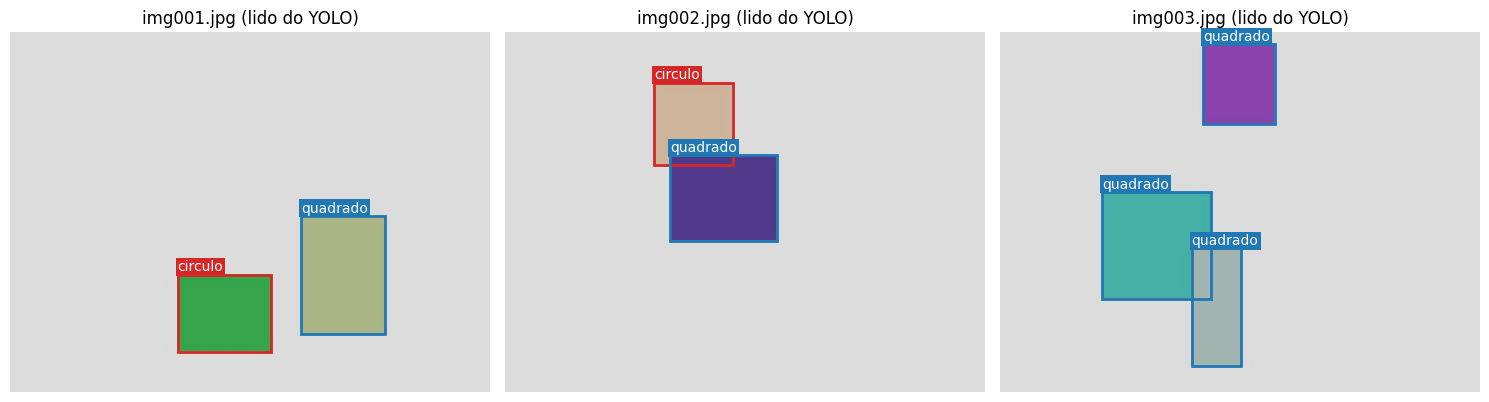

In [12]:
def ler_yolo(pasta_yolo, file_name, classes):
    """Le um .txt YOLO e devolve [(class_name, x1, y1, x2, y2), ...] em pixels."""
    pasta_yolo = Path(pasta_yolo)
    img = Image.open(pasta_yolo / "images" / file_name)
    Wd, Hd = img.size
    txt = pasta_yolo / "labels" / Path(file_name).with_suffix(".txt").name
    objs = []
    for linha in txt.read_text(encoding="utf-8").strip().splitlines():
        partes = linha.split()
        if len(partes) != 5:
            continue
        cls_idx = int(partes[0])
        xc, yc, wn, hn = map(float, partes[1:])
        x1 = (xc - wn / 2) * Wd
        y1 = (yc - hn / 2) * Hd
        x2 = (xc + wn / 2) * Wd
        y2 = (yc + hn / 2) * Hd
        objs.append((classes[cls_idx], x1, y1, x2, y2))
    return img, objs


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, amostra in zip(axes, dataset):
    img, objs = ler_yolo(YOLO_DIR, amostra["file_name"], CLASSES)
    ax.imshow(img)
    for nome, x1, y1, x2, y2 in objs:
        cls_idx = CLASSES.index(nome)
        cor = CORES_PLOT[cls_idx]
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, edgecolor=cor, linewidth=2))
        ax.text(x1, max(0, y1 - 5), nome,
                color="white", fontsize=10,
                bbox=dict(facecolor=cor, edgecolor="none", pad=1.5))
    ax.set_title(f"{amostra['file_name']} (lido do YOLO)")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 9. Ferramentas de anotação

Anotar manualmente em texto puro (XML/JSON/TXT) é inviável em escala. As ferramentas a seguir são as mais usadas em projetos de visão computacional — cada uma exporta nos formatos que acabamos de estudar.

### 9.1 Roboflow

**Plataforma SaaS** (com tier gratuito limitado) muito popular no mercado. Cobre todo o pipeline: *upload*, anotação colaborativa, *augmentation*, versionamento de *dataset* e *deploy* de modelos. Forte na conversão automática entre formatos (você anota uma vez e exporta para COCO, VOC, YOLO, etc.). **Limitações:** *dataset* fica hospedado na Roboflow, e o tier gratuito tem teto de imagens públicas.

Site: <https://roboflow.com>

![Roboflow](../figures/programas/roboflow.jpg)

---

### 9.2 CVAT (Computer Vision Annotation Tool)

**Open source**, desenvolvido pela Intel/OpenCV. Pode rodar **localmente via Docker** ou ser usado na versão hospedada (cvat.ai). Suporta caixas, polígonos, *keypoints*, máscaras e até vídeo (interpolação entre *frames*). É o padrão de fato em pesquisa acadêmica e em times que precisam manter os dados internos. **Limitações:** *setup* local exige um pouco de DevOps; UI é mais técnica que a do Roboflow.

Site: <https://www.cvat.ai>

![CVAT](../figures/programas/cvat_screenshot.png)

---

### 9.3 Label Studio

**Open source** (Heartex), instalável com `pip install label-studio`. Diferencial: **multimodal** (imagem, texto, áudio, séries temporais, vídeo) com uma única ferramenta. Boa escolha para times que rotulam dados além de visão. Suporta integração com modelos para *active learning*. **Limitações:** plug-ins de detecção em imagem são menos polidos que CVAT/Roboflow para grandes volumes.

Site: <https://labelstud.io>

![Label Studio](../figures/programas/label_studio.png)

---

### 9.4 LabelImg (menção)

Ferramenta clássica em Python (`pip install labelImg`), com interface simples em Qt. **Apenas caixas**, exporta direto em **Pascal VOC** ou **YOLO**. Ótima para aulas e protótipos pequenos por ser totalmente local e sem cadastro. Está em modo de **manutenção** (sem novas *features*), mas continua funcionando.

Repositório: <https://github.com/HumanSignal/labelImg>


## 10. Boas práticas

- **Defina as classes antes de anotar**: lista fechada, sem categoria *"outro"* (gera ruído e dificulta aprendizado).
- **Comece com 100-500 imagens diversas** por classe — mais cedo se descobrem problemas de definição.
- **Escreva um guia de anotação** com exemplos do que **é** e do que **não é** cada classe (especialmente em casos borderline).
- **Padronize o *split* em 70/15/15** (treino / validação / teste) e **estratifique** por classe se possível.
- **Treine um *baseline* rápido e revise os erros**: as imagens em que o modelo erra muito costumam ser as mais valiosas para anotar a seguir (*active learning*).
- **Cuidado com *augmentation* geométrico**: rotações, *flips* e *crops* **movem as caixas** — use bibliotecas como `albumentations` que atualizam as anotações junto com a imagem.
- **Convenção `torchvision`**: a **classe 0 é reservada para o fundo** em modelos como Faster R-CNN; suas classes reais começam em 1. Em YOLO, ao contrário, **0 é a primeira classe real** (não há "fundo").
- **Não compare mAP entre *datasets* diferentes**: a métrica depende da distribuição de tamanhos, oclusão e do critério de IoU. Comparações só fazem sentido no **mesmo *dataset* e mesmo *split***.


## Resumo

Neste último notebook da aula, percorremos a **camada de dados** da detecção de objetos:

- **Três formatos dominantes**, cada um com sua convenção de bbox:

  | Formato      | Arquivos                    | Bbox                  | Coordenadas      |
  |--------------|-----------------------------|-----------------------|------------------|
  | **COCO**     | 1 `.json`                   | `[x, y, w, h]`        | pixels           |
  | **Pascal VOC** | 1 `.xml` por imagem       | `xmin, ymin, xmax, ymax` | pixels      |
  | **YOLO**     | 1 `.txt` por imagem + `.yaml` | `xc, yc, w, h`     | normalizado [0,1] |

- **Escrita e leitura** dos três com a biblioteca padrão (`json`, `xml.etree.ElementTree`) e `pyyaml`.
- **Conversões** COCO → YOLO e Pascal VOC → COCO, verificadas tanto numericamente quanto visualmente.
- **Ferramentas de anotação**: Roboflow (SaaS), CVAT (open source, padrão de pesquisa), Label Studio (multimodal) e LabelImg (legado, simples).
- **Boas práticas** de definição de classes, *splits*, *augmentation* com `albumentations` e cuidados com a métrica mAP.

### Fim da aula

Com este notebook fechamos a sequência **Localização → Detecção → YOLO/métricas → Segmentação → Formatos e Ferramentas**. O caminho natural a partir daqui é aplicar o pipeline completo num *dataset* real: anotar (CVAT ou Roboflow), exportar (preferencialmente em COCO ou YOLO), treinar um *baseline* (Faster R-CNN do notebook 2 ou YOLO do notebook 3), avaliar com mAP, revisar erros e iterar. Bons projetos!
